In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('dataset.csv')

### Dataset Information
Let's get a summary of the DataFrame to inspect data types and check for missing values.

In [4]:
# Display information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


None

### Descriptive Statistics
Let's generate descriptive statistics for the numerical columns.

In [5]:
# Generate descriptive statistics of the DataFrame
display(df.describe())

,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


### Missing Values Analysis
Let's check for any missing values in the dataset.

In [6]:
# Check for missing values
display(df.isnull().sum())

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


### Handling Missing Values
Based on the missing value analysis, we will handle them. `Unnamed: 0` seems to be an index column, and 'Date' is critical. Let's drop rows with missing 'Date' or 'Unnamed: 0'. For numerical columns like 'high', 'low', 'open', 'close', we can fill missing values with the mean. For 'volume' and 'adj close', we can fill with 0 if they are indeed related to no activity.

In [9]:
# Drop 'Unnamed: 0' column as it appears to be an artifact
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Drop rows where 'date' is missing, as it's a critical column
df.dropna(subset=['date'], inplace=True)

# Fill missing values in 'volume' with 0, assuming 0 means no activity/data
if 'volume' in df.columns:
    df['volume'].fillna(0, inplace=True)

# Fill missing numerical values in 'high', 'low', 'open', 'close' with the mean of their respective columns
for col in ['high', 'low', 'open', 'close']:
    if col in df.columns:
        df[col].fillna(df[col].mean(), inplace=True)

# Re-check for missing values after handling
display(df.isnull().sum())

,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


### Data Type Conversion
Ensure that 'Date' is in datetime format and other numerical columns are correctly typed.

In [10]:
# Convert 'date' and 'timestamp' to datetime objects
df['date'] = pd.to_datetime(df['date'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Convert relevant columns to numeric types if they aren't already
for col in ['open', 'high', 'low', 'close', 'volume', 'marketCap']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Display DataFrame info again to confirm data types and non-null counts
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   open         72946 non-null  float64            
 1   high         72946 non-null  float64            
 2   low          72946 non-null  float64            
 3   close        72946 non-null  float64            
 4   volume       72946 non-null  float64            
 5   marketCap    72946 non-null  float64            
 6   timestamp    72946 non-null  datetime64[ns, UTC]
 7   crypto_name  72946 non-null  object             
 8   date         72946 non-null  datetime64[ns]     
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), float64(6), object(1)
memory usage: 5.0+ MB


None

### Feature Engineering: Extracting Time-based Features
Let's extract additional time-based features from the 'date' column to enrich our dataset and potentially uncover patterns.

In [11]:
# Extract time-based features from the 'date' column
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

# Display the first few rows with the new features
display(df.head())

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,year,month,day,day_of_week,quarter
0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05 23:59:59.999000+00:00,Bitcoin,2013-05-05,2013,5,5,6,2
1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05 23:59:59.999000+00:00,Litecoin,2013-05-05,2013,5,5,6,2
2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06 23:59:59.999000+00:00,Bitcoin,2013-05-06,2013,5,6,0,2
3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06 23:59:59.999000+00:00,Litecoin,2013-05-06,2013,5,6,0,2
4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07 23:59:59.999000+00:00,Bitcoin,2013-05-07,2013,5,7,1,2


### Univariate Analysis: Distributions of Numerical Features
Let's visualize the distributions of our key numerical features using histograms to understand their spread and identify potential skewness or outliers.

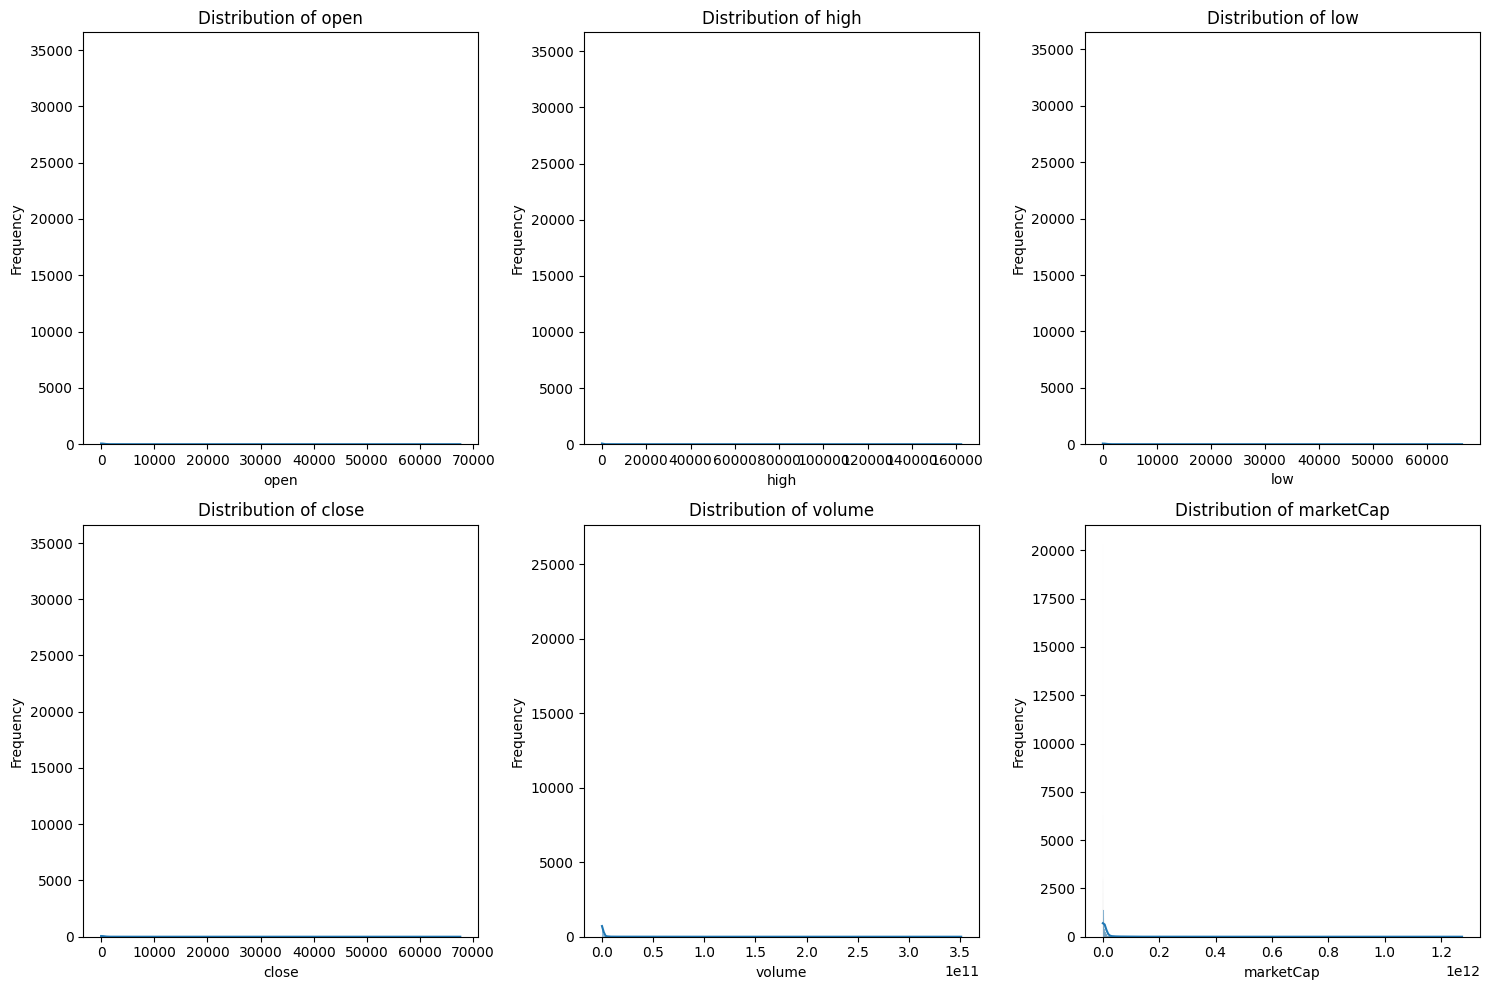

In [12]:
numerical_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Univariate Analysis: Counts of Categorical Features
Now, let's look at the counts of our categorical features, such as `crypto_name`.

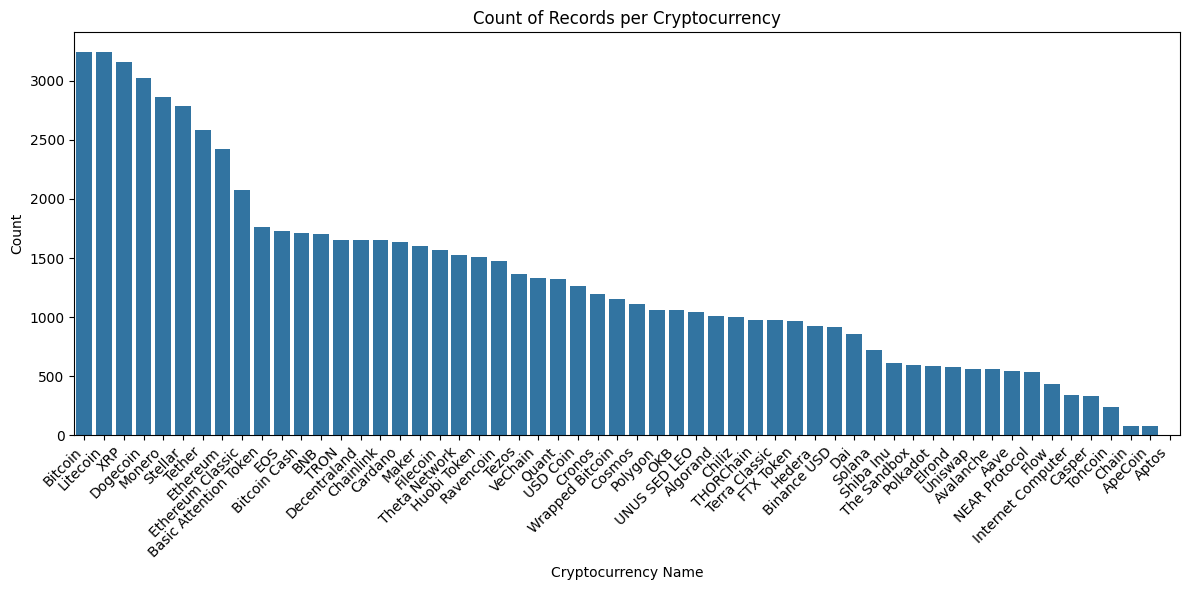

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='crypto_name', order=df['crypto_name'].value_counts().index)
plt.title('Count of Records per Cryptocurrency')
plt.xlabel('Cryptocurrency Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bivariate Analysis: Correlation Matrix
Let's examine the correlations between numerical features to understand how they relate to each other. A heatmap is a great way to visualize this.

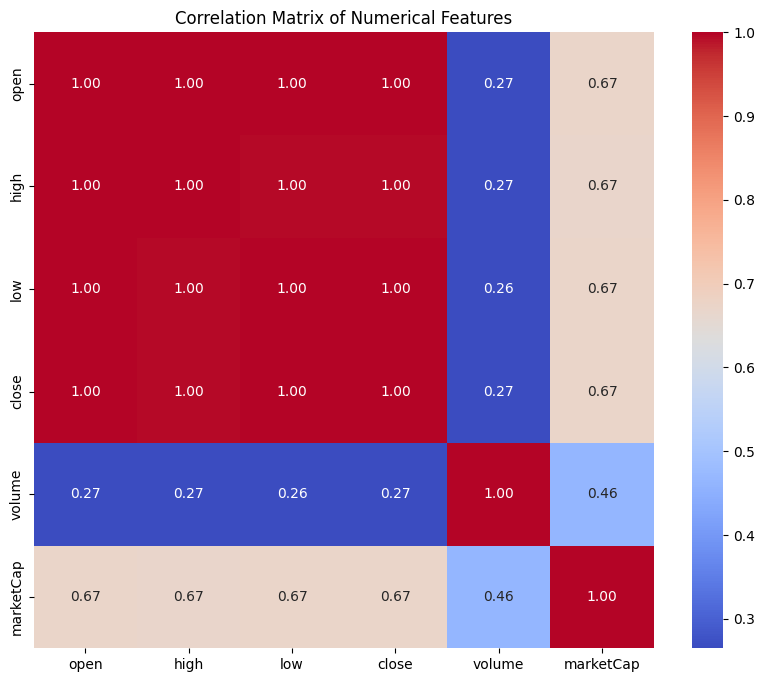

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Bivariate Analysis: Price vs. Volume over Time
Let's visualize the 'close' price and 'volume' over time for a selected cryptocurrency to see their trends and relationship.

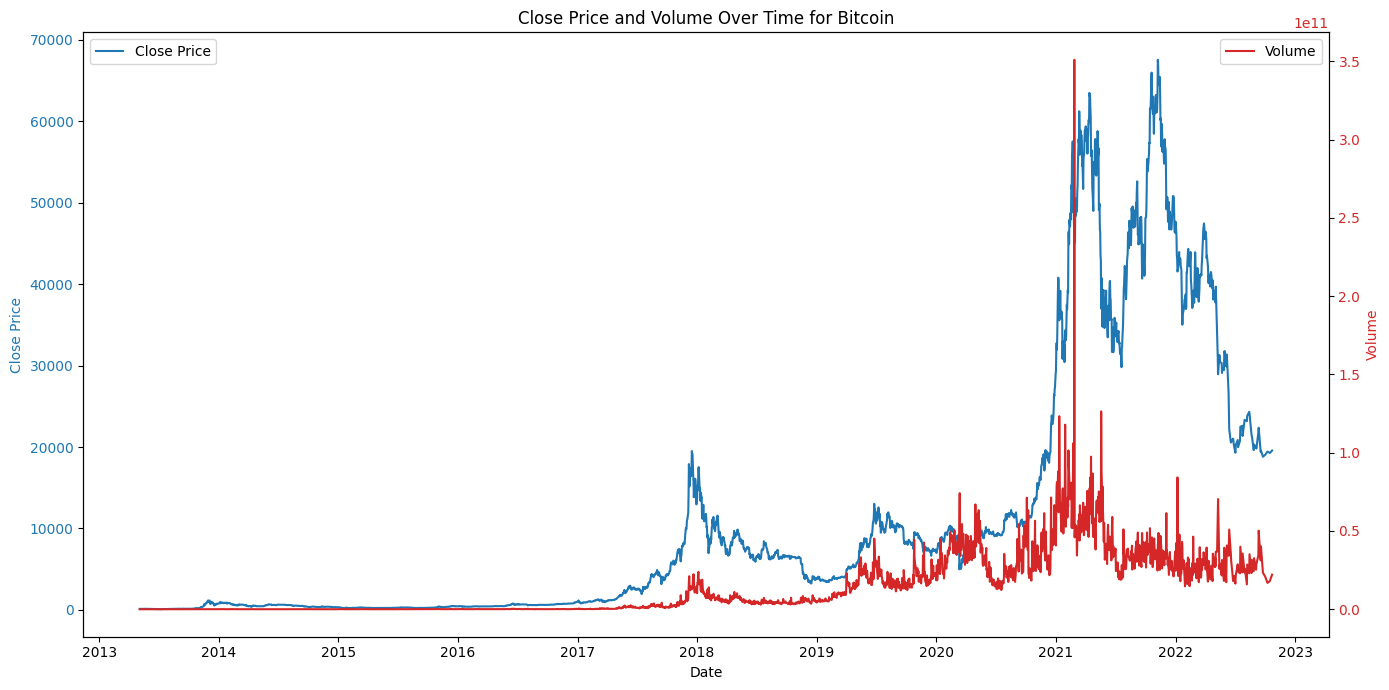

In [15]:
# Select a cryptocurrency for plotting (e.g., the one with the most records)
most_common_crypto = df['crypto_name'].value_counts().index[0]
df_filtered = df[df['crypto_name'] == most_common_crypto].sort_values(by='date')

fig, ax1 = plt.subplots(figsize=(14, 7))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color=color)
ax1.plot(df_filtered['date'], df_filtered['close'], color=color, label='Close Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Volume', color=color)  # we already handled the x-label with ax1
ax2.plot(df_filtered['date'], df_filtered['volume'], color=color, label='Volume')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title(f'Close Price and Volume Over Time for {most_common_crypto}')
fig.tight_layout()  # otherwise, the right y-label is slightly clipped
plt.show()

### Bivariate Analysis: Categorical vs. Numerical (Box Plots)
Let's use box plots to compare the distribution of 'close' prices across different cryptocurrencies to see if there are significant differences.

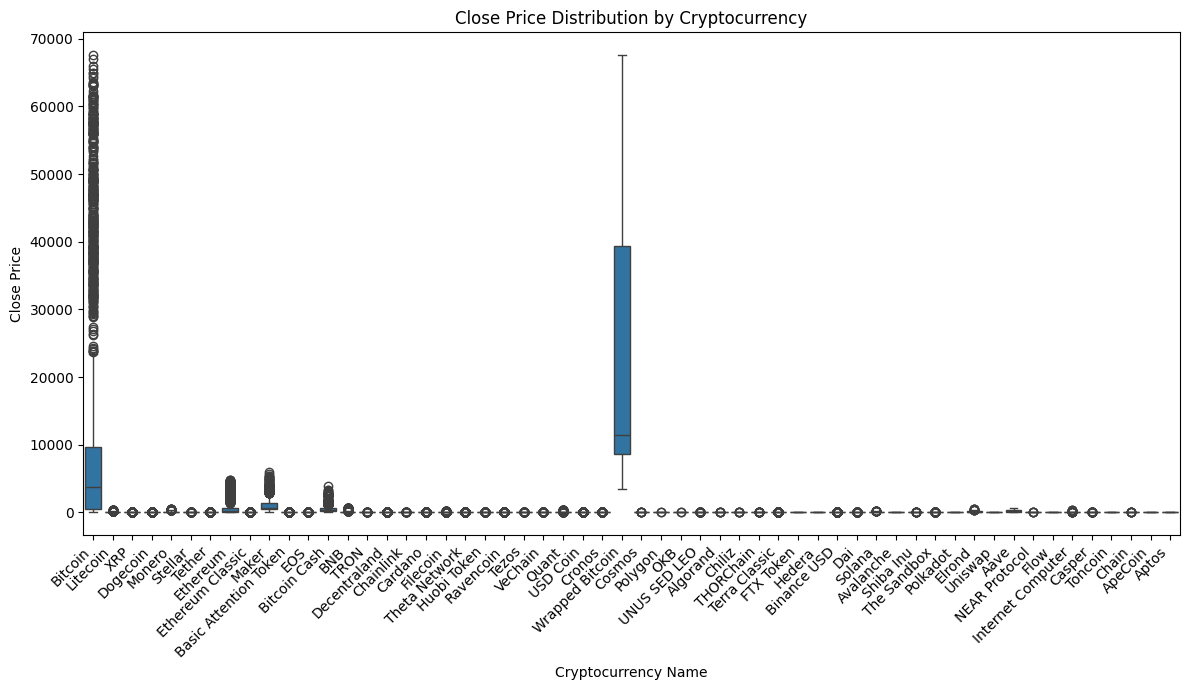

In [16]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='crypto_name', y='close')
plt.title('Close Price Distribution by Cryptocurrency')
plt.xlabel('Cryptocurrency Name')
plt.ylabel('Close Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Multivariate Analysis: Pair Plot of Key Numerical Features
Let's visualize the relationships between multiple key numerical features using a pair plot. This will show scatter plots for each pair of features and histograms for individual features, which can reveal complex correlations and distributions.

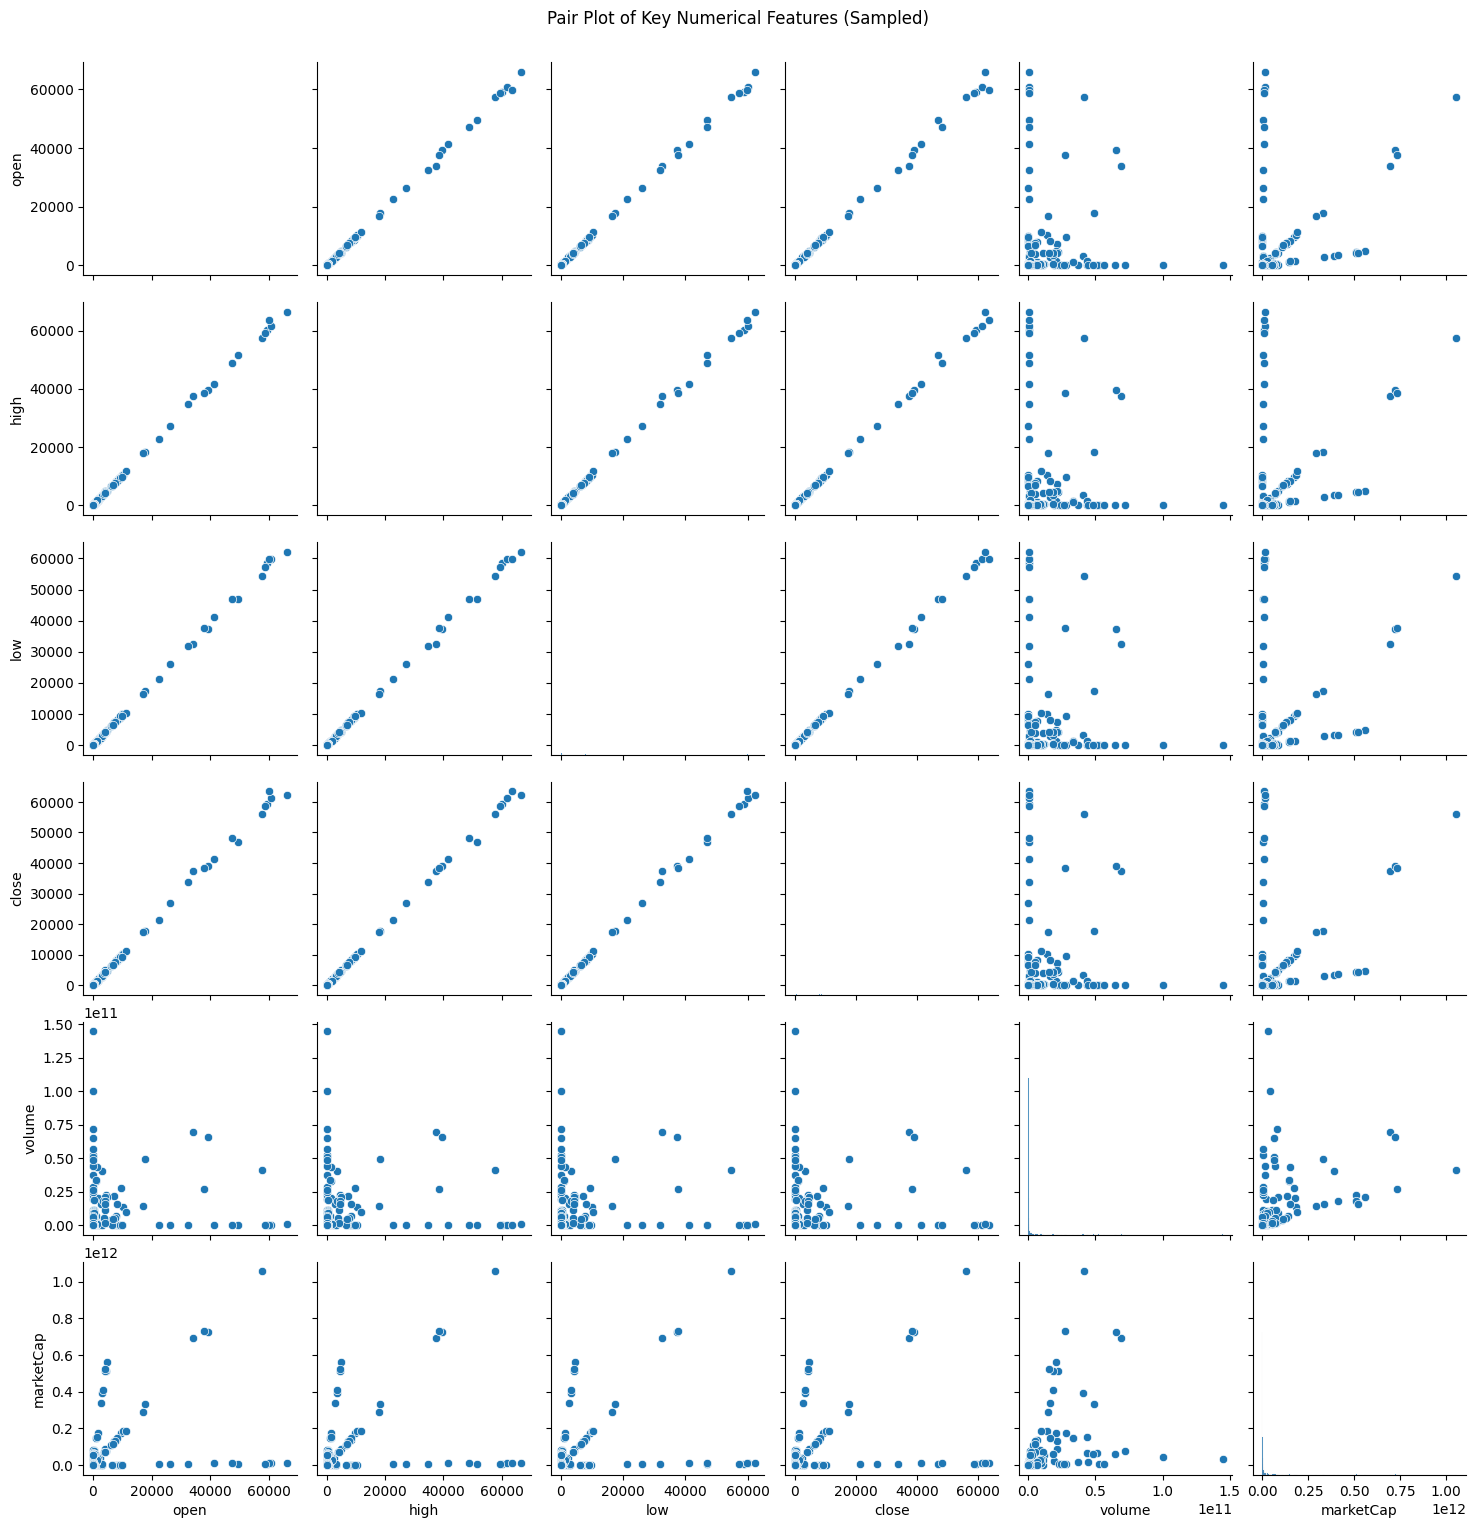

In [17]:
selected_numerical_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap']
sns.pairplot(df[selected_numerical_cols].sample(n=1000, random_state=42))
plt.suptitle('Pair Plot of Key Numerical Features (Sampled)', y=1.02)
plt.show()

### Save Processed DataFrame to CSV
Now that the data has been cleaned and engineered, let's save the processed DataFrame to a new CSV file for future use or model training.